<a href="https://colab.research.google.com/github/RohanRanshinge/causal-inference/blob/main/zero-to-hero-bsts/PART_I-Bayesian-Statistics/04.3-Probability-Distributions-InverseGamma.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Normal - Inverse Gamma Conjugate
The Normal-Inverse Gamma conjugate is a very useful conjugate pair that actually shows up in Causal Impact and many other solutions. 

Let's try to understand how they play together.

## Inverse Gamma Distribution
A normal distribution is a continuous probability distribution that is shaped like a bell curve that best describes the strength of possible beliefs in the the value of an uncertain measurement, given a known mean and standard deviation.


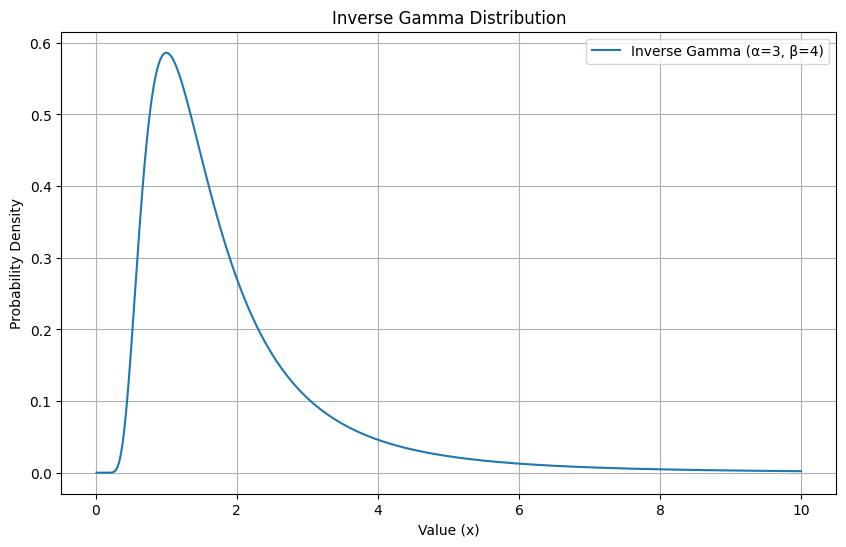

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import invgamma

# Parameters for the Inverse Gamma distribution
alpha = 3  # Shape parameter
beta = 4   # Scale parameter

# Generate x values (must be positive)
x = np.linspace(0.01, 10, 1000)

# Calculate the PDF
pdf_values = invgamma.pdf(x, a=alpha, scale=beta)

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(x, pdf_values, label=f'Inverse Gamma (α={alpha}, β={beta})')

# Add title and labels
plt.title("Inverse Gamma Distribution")
plt.xlabel("Value (x)")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(True)

plt.show()

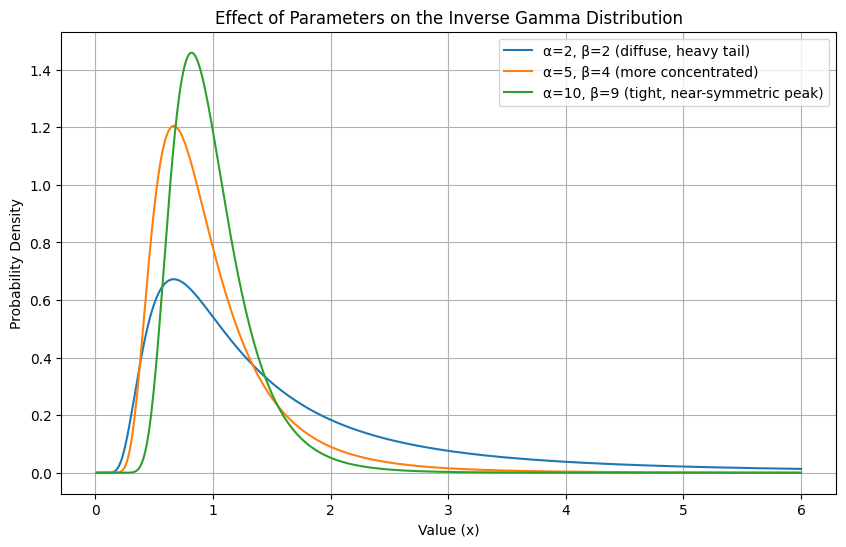

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import invgamma

# Two different parameterizations to show the effect of alpha and beta
params = [
    (2, 2, 'α=2, β=2 (diffuse, heavy tail)'),
    (5, 4, 'α=5, β=4 (more concentrated)'),
    (10, 9, 'α=10, β=9 (tight, near-symmetric peak)'),
]

x = np.linspace(0.01, 6, 1000)

plt.figure(figsize=(10, 6))
for alpha, beta, label in params:
    pdf_values = invgamma.pdf(x, a=alpha, scale=beta)
    plt.plot(x, pdf_values, label=label)

plt.title("Effect of Parameters on the Inverse Gamma Distribution")
plt.xlabel("Value (x)")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(True)

plt.show()

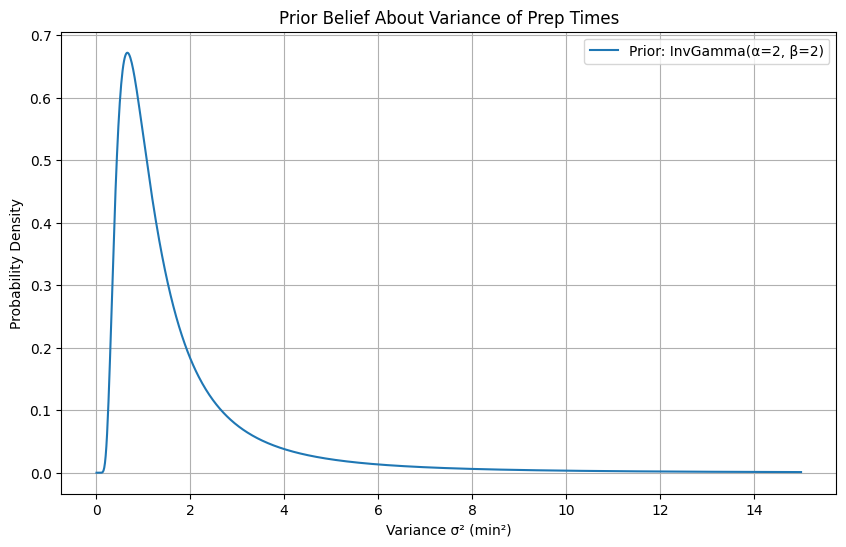

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import invgamma

# Prior parameters
alpha_prior = 2
beta_prior = 2

x = np.linspace(0.01, 15, 1000)
pdf_prior = invgamma.pdf(x, a=alpha_prior, scale=beta_prior)

plt.figure(figsize=(10, 6))
plt.plot(x, pdf_prior, label=f'Prior: InvGamma(α={alpha_prior}, β={beta_prior})')

plt.title("Prior Belief About Variance of Prep Times")
plt.xlabel("Variance σ² (min²)")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(True)

plt.show()

# Inverse Gamma Distribution

The Inverse Gamma distribution is a continuous probability distribution defined for positive values (from 0 to infinity). As the name suggests, it is directly related to the Gamma distribution — if a random variable X follows a Gamma distribution, then 1/X follows an Inverse Gamma distribution.

Like the Gamma distribution, it is defined by two positive parameters, α (shape) and β (scale), and is commonly used as a conjugate prior in Bayesian statistics, particularly for parameters that represent **variance** in a Normal distribution.

The Probability Density Function (PDF) for the Inverse Gamma distribution is:

$$f(x; \alpha, \beta) = \frac{\beta^\alpha}{\Gamma(\alpha)} x^{-\alpha - 1} \exp\!\left(-\frac{\beta}{x}\right)$$

Where:

- x > 0 is the random variable
- α > 0 is the shape parameter
- β > 0 is the scale parameter
- Γ(α) is the Gamma function evaluated at α (a generalization of the factorial)

Notice that unlike the Normal distribution's PDF, the negative exponential here involves β/x rather than x itself — this is what "flips" the Gamma distribution and constrains values to be positive while producing a right-skewed shape.


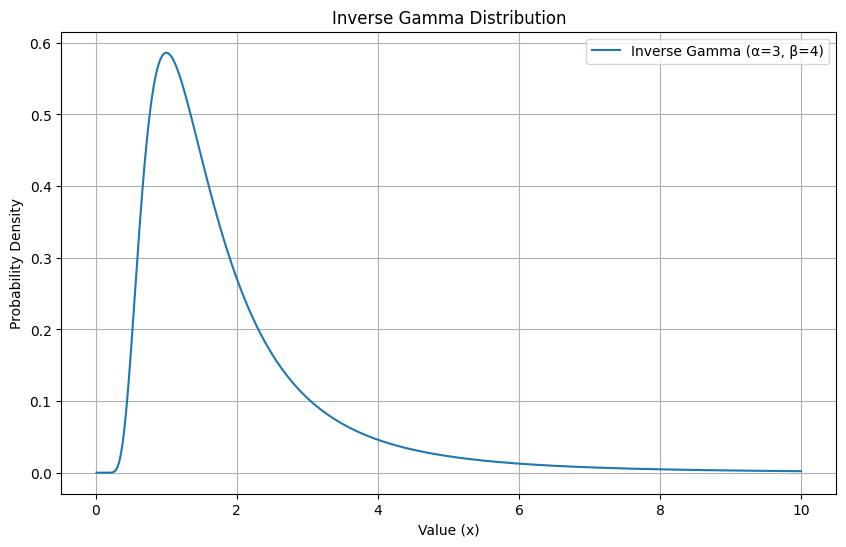

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import invgamma

# Parameters for the Inverse Gamma distribution
alpha = 3  # Shape parameter
beta = 4   # Scale parameter

# Generate x values (must be positive)
x = np.linspace(0.01, 10, 1000)

# Calculate the PDF
pdf_values = invgamma.pdf(x, a=alpha, scale=beta)

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(x, pdf_values, label=f'Inverse Gamma (α={alpha}, β={beta})')

# Add title and labels
plt.title("Inverse Gamma Distribution")
plt.xlabel("Value (x)")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(True)

plt.show()



A few things to notice about the shape:

- The distribution is right-skewed and only defined for positive values — this makes it well-suited for modeling quantities like variance, which can never be negative
- The peak of the distribution (the mode) is at β / (α + 1)
- The mean of the distribution is β / (α - 1), but only exists when α > 1

**The shape parameter α controls how peaked or spread out the distribution is, while β controls where the bulk of the mass sits along the x-axis.**



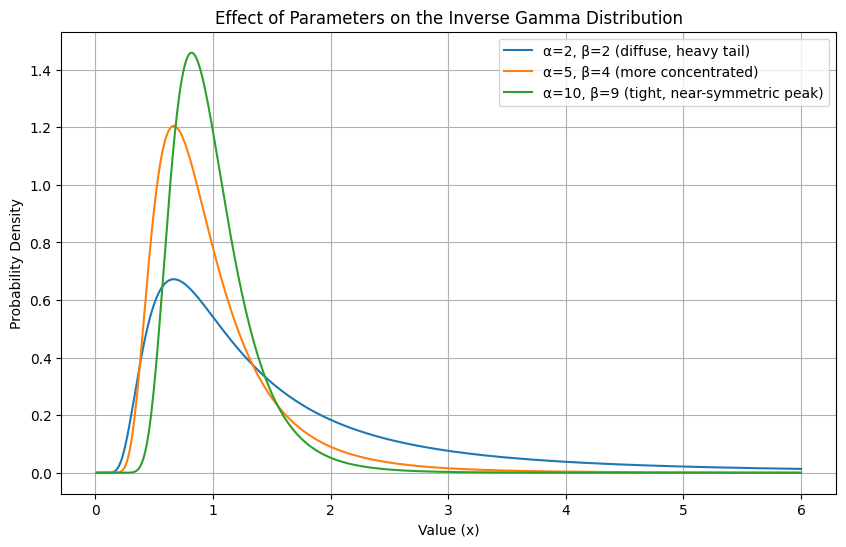

In [5]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import invgamma

# Two different parameterizations to show the effect of alpha and beta
params = [
    (2, 2, 'α=2, β=2 (diffuse, heavy tail)'),
    (5, 4, 'α=5, β=4 (more concentrated)'),
    (10, 9, 'α=10, β=9 (tight, near-symmetric peak)'),
]

x = np.linspace(0.01, 6, 1000)

plt.figure(figsize=(10, 6))
for alpha, beta, label in params:
    pdf_values = invgamma.pdf(x, a=alpha, scale=beta)
    plt.plot(x, pdf_values, label=label)

plt.title("Effect of Parameters on the Inverse Gamma Distribution")
plt.xlabel("Value (x)")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(True)

plt.show()


As α increases (with β scaled proportionally), the distribution becomes more concentrated around its mean and the heavy right tail pulls in. With small α, the distribution is spread out with a heavy tail — expressing more uncertainty. With large α, the distribution is tighter — expressing strong beliefs about where the true value sits.


---

## How Noisy Is Your Coffee Shop? Learning Variance Estimation

Imagine you manage a busy coffee shop and you pride yourself on consistent service. You know from years of experience that the **average** time to prepare an order is **5 minutes**. That part you're confident about. What you're less sure about is the *variance* — how much does that prep time actually bounce around from order to order?

Some days everything flows perfectly and every drink comes out right at the 5 minute mark. Other days the espresso machine acts up, someone orders a complicated seasonal drink, and times scatter wildly. You want to quantify this — not just whether service is slow on average, but how *unpredictable* it is.

You record the preparation times for 5 random orders during a morning rush: **3, 6, 5, 8, and 4 minutes.**

Knowing the mean is 5 minutes, you compute the sum of squared deviations from the mean:

$$SS = (3-5)^2 + (6-5)^2 + (5-5)^2 + (8-5)^2 + (4-5)^2 = 4 + 1 + 0 + 9 + 1 = 15$$

You want to answer: **given what you believe going in and what you just observed, what is the distribution of plausible variance values for your prep times?**

This is exactly the kind of problem the Inverse Gamma was built for.

---


## How Do We Use Inverse Gamma as a Prior?

When we model our prep times as a Normal distribution with a **known mean** μ and **unknown variance** σ², we need a prior over σ². The variance must be positive, it's a continuous quantity, and we expect it to be right-skewed — small variance is plausible but very large variance is unlikely. The Inverse Gamma checks all these boxes.

Based on your general experience before recording any data, you have a vague sense that order prep times vary by about 2 minutes² on average — enough to reflect some uncertainty but not total chaos. You choose a weakly informative prior:

$$\sigma^2 \sim \text{InvGamma}(\alpha = 2, \beta = 2)$$

This gives a prior mean variance of β / (α - 1) = 2 / 1 = **2 min²**.



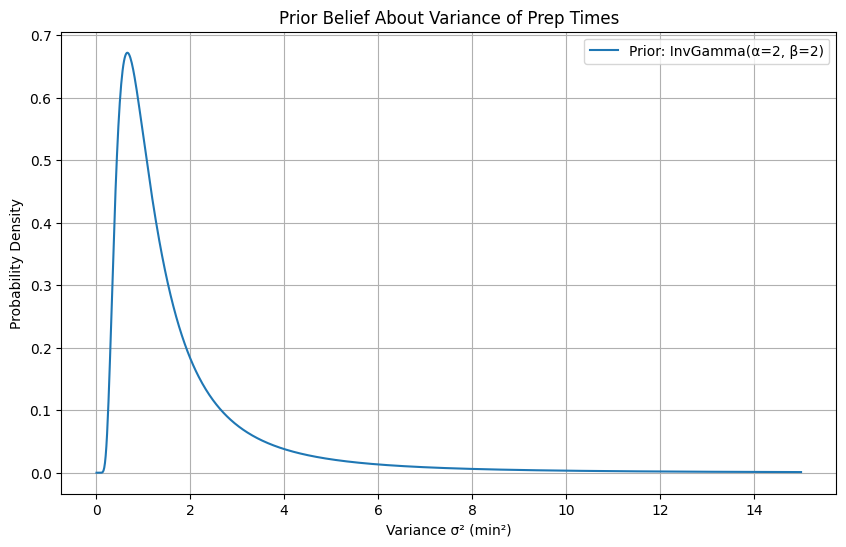

In [6]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import invgamma

# Prior parameters
alpha_prior = 2
beta_prior = 2

x = np.linspace(0.01, 15, 1000)
pdf_prior = invgamma.pdf(x, a=alpha_prior, scale=beta_prior)

plt.figure(figsize=(10, 6))
plt.plot(x, pdf_prior, label=f'Prior: InvGamma(α={alpha_prior}, β={beta_prior})')

plt.title("Prior Belief About Variance of Prep Times")
plt.xlabel("Variance σ² (min²)")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(True)

plt.show()




The wide spread of this curve reflects that while we have a rough expectation, we are open to being corrected by the data.

---

## Updating with Data — The Normal-Inverse Gamma Shortcut

Just as the Gamma distribution is a conjugate prior to the Poisson likelihood, the **Inverse Gamma is a conjugate prior to the variance of a Normal distribution**. This gives us a clean analytical shortcut to compute the posterior without ever evaluating a complex integral.

When we observe n data points from a Normal distribution with known mean μ, the posterior update rule is:

$$\alpha_{\text{posterior}} = \alpha_{\text{prior}} + \frac{n}{2}$$

$$\beta_{\text{posterior}} = \beta_{\text{prior}} + \frac{SS}{2}$$

where SS = Σ(xᵢ - μ)² is the sum of squared deviations from the mean.

With our 5 observations and SS = 15:

$$\alpha_{\text{posterior}} = 2 + \frac{5}{2} = 4.5$$

$$\beta_{\text{posterior}} = 2 + \frac{15}{2} = 9.5$$

The posterior mean variance is now β / (α - 1) = 9.5 / 3.5 ≈ **2.71 min²** — the data has nudged our belief upward from 2, because those observed prep times were more scattered than our prior expected.


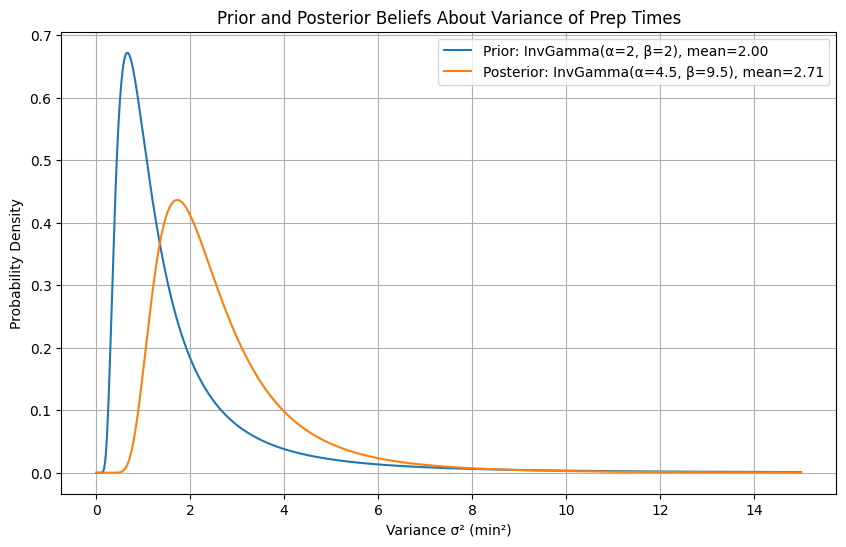

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import invgamma

# Prior parameters
alpha_prior = 2
beta_prior = 2

# Data
n = 5
SS = 15  # Sum of squared deviations: (3-5)^2 + (6-5)^2 + (5-5)^2 + (8-5)^2 + (4-5)^2

# Posterior parameters (conjugate update)
alpha_posterior = alpha_prior + n / 2
beta_posterior = beta_prior + SS / 2

x = np.linspace(0.01, 15, 1000)

pdf_prior = invgamma.pdf(x, a=alpha_prior, scale=beta_prior)
pdf_posterior = invgamma.pdf(x, a=alpha_posterior, scale=beta_posterior)

plt.figure(figsize=(10, 6))
plt.plot(x, pdf_prior, label=f'Prior: InvGamma(α={alpha_prior}, β={beta_prior}), mean={beta_prior/(alpha_prior-1):.2f}')
plt.plot(x, pdf_posterior, label=f'Posterior: InvGamma(α={alpha_posterior}, β={beta_posterior}), mean={beta_posterior/(alpha_posterior-1):.2f}')

plt.title("Prior and Posterior Beliefs About Variance of Prep Times")
plt.xlabel("Variance σ² (min²)")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(True)

plt.show()




Notice two things in the plot: the posterior has a **higher mean** (the data showed more variability than expected) and a **narrower spread** (we are now more certain because we have actual observations to learn from). The prior was wide and vague; the posterior is tighter and updated.

As you collect more data — more orders recorded over more days — you repeat this process. The posterior becomes the new prior and continues to sharpen:


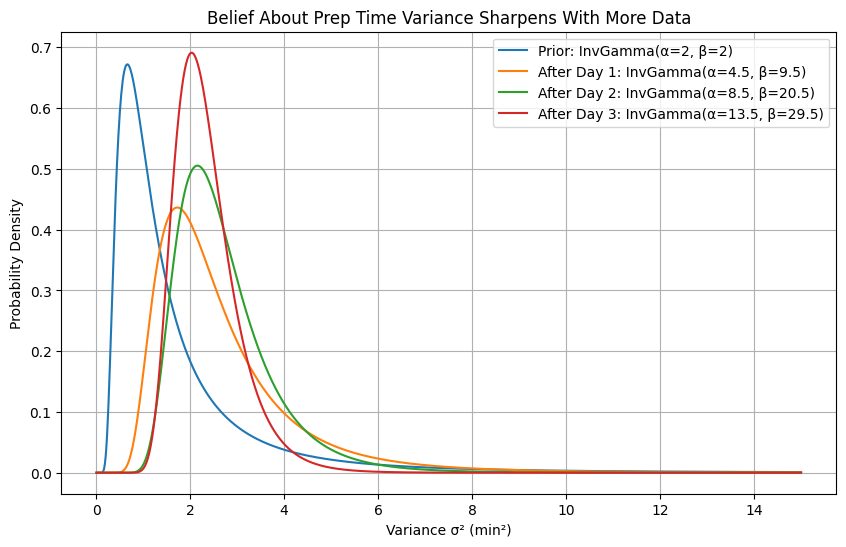

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import invgamma

# Simulate additional days of data collection
# Day 1: 5 orders, SS=15 → posterior becomes (4.5, 9.5)
# Day 2: 8 orders, SS=22
# Day 3: 10 orders, SS=18

observations = [
    (5, 15),   # (n, SS) for each batch
    (8, 22),
    (10, 18),
]

alpha = 2
beta = 2
labels = [f'Prior: InvGamma(α={alpha}, β={beta})']

x = np.linspace(0.01, 15, 1000)
pdfs = [invgamma.pdf(x, a=alpha, scale=beta)]

for i, (n, SS) in enumerate(observations):
    alpha = alpha + n / 2
    beta = beta + SS / 2
    pdfs.append(invgamma.pdf(x, a=alpha, scale=beta))
    labels.append(f'After Day {i+1}: InvGamma(α={alpha:.1f}, β={beta:.1f})')

plt.figure(figsize=(10, 6))
for pdf, label in zip(pdfs, labels):
    plt.plot(x, pdf, label=label)

plt.title("Belief About Prep Time Variance Sharpens With More Data")
plt.xlabel("Variance σ² (min²)")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(True)

plt.show()




Each new batch of orders pulls the distribution tighter and repositions it based on what the data shows. After three days of observation, you have a much more precise picture of how variable your prep times really are — and can make concrete decisions about staffing or workflow improvements.

---

## Key Takeaways

The Inverse Gamma is the natural distribution for reasoning about **variance** — the spread of a process — in a Bayesian framework.

- It is defined only for positive values, which makes sense since variance can never be negative
- The shape parameter α controls how concentrated the distribution is; larger α means stronger beliefs
- The scale parameter β controls the location of the mass; larger β means beliefs centered on higher variance values
- The mean of the distribution is β / (α - 1) and only exists for α > 1
- The mode — the most probable value — is always β / (α + 1)

The **Normal-Inverse Gamma conjugate relationship** gives us the same kind of clean analytical shortcut we saw with Gamma-Poisson:

$$\alpha_{\text{posterior}} = \alpha_{\text{prior}} + \frac{n}{2}, \quad \beta_{\text{posterior}} = \beta_{\text{prior}} + \frac{SS}{2}$$

This lets us update our beliefs about variance after observing data without ever computing a difficult integral — the posterior is always another Inverse Gamma, and we can simply plug in the updated parameters. As with all conjugate priors, this is not just mathematically convenient; it is also interpretable. Each new batch of data adds n/2 to our shape (making us more certain) and SS/2 to our scale (shifting our belief to reflect what the data actually showed).